# 🌌 Colour Your Own Universe

In this activity, we will work with real astronomical survey images using Python.

We will first look at one telescope image in black and white, then choose a colour map to see the brightness structure more clearly. After that, we will use three different survey bands to make an RGB composite.

You do not need to know Python before starting. Run the cells one by one and read the short note above each cell.

## Step 1 — Install the astronomy packages

We need two astronomy packages: **Astropy** and **Astroquery**.

Run this cell once.

In [395]:
!pip -q install astroquery astropy

## Step 2 — Import the tools

Here we load the Python tools that we need for downloading, displaying and saving the images.

In [396]:
import numpy as np
import matplotlib.pyplot as plt

from astroquery.skyview import SkyView
from astropy.visualization import ImageNormalize, PercentileInterval, AsinhStretch
import astropy.units as u
from google.colab import files
from urllib.error import HTTPError

print("Everything is ready.")

Everything is ready.


## Step 3 — Our target list

The notebook has **15 targets**.

They include galaxies, nebulae, star clusters and supernova remnants.

In [397]:
objects = {
    # Galaxies
    "Andromeda Galaxy (M31)": {
        "position": "M31",
        "size": 0.70,
        "type": "Galaxy",
        "note": "A giant spiral galaxy near the Milky Way."
    },
    "Triangulum Galaxy (M33)": {
        "position": "M33",
        "size": 0.45,
        "type": "Galaxy",
        "note": "A nearby face-on spiral galaxy."
    },
    "Whirlpool Galaxy (M51)": {
        "position": "M51",
        "size": 0.30,
        "type": "Galaxy",
        "note": "A famous interacting spiral galaxy."
    },
    "Bode's Galaxy (M81)": {
        "position": "M81",
        "size": 0.35,
        "type": "Galaxy",
        "note": "A bright spiral galaxy in Ursa Major."
    },
    "Sombrero Galaxy (M104)": {
        "position": "M104",
        "size": 0.22,
        "type": "Galaxy",
        "note": "A galaxy with a bright bulge and dark dust lane."
    },

    # Nebulae
    "Orion Nebula (M42)": {
        "position": "M42",
        "size": 0.40,
        "type": "Nebula",
        "note": "A famous star-forming nebula."
    },
    "Lagoon Nebula (M8)": {
        "position": "M8",
        "size": 0.45,
        "type": "Nebula",
        "note": "A bright emission nebula."
    },
    "Trifid Nebula (M20)": {
        "position": "M20",
        "size": 0.25,
        "type": "Nebula",
        "note": "A nebula with dark dust lanes."
    },
    "Dumbbell Nebula (M27)": {
        "position": "M27",
        "size": 0.18,
        "type": "Nebula",
        "note": "A planetary nebula."
    },
    "Ring Nebula (M57)": {
        "position": "M57",
        "size": 0.08,
        "type": "Nebula",
        "note": "A small but famous ring-shaped planetary nebula."
    },

    # Star clusters
    "Pleiades (M45)": {
        "position": "M45",
        "size": 0.70,
        "type": "Star Cluster",
        "note": "A bright open cluster also called the Seven Sisters."
    },
    "Hercules Globular Cluster (M13)": {
        "position": "M13",
        "size": 0.18,
        "type": "Star Cluster",
        "note": "One of the brightest globular clusters."
    },
    "Globular Cluster (M15)": {
        "position": "M15",
        "size": 0.12,
        "type": "Star Cluster",
        "note": "A dense globular cluster."
    },

    # Supernova remnants
    "Crab Nebula (M1)": {
        "position": "M1",
        "size": 0.12,
        "type": "Supernova Remnant",
        "note": "The remnant of a supernova explosion."
    },
    "Veil Nebula (NGC 6992)": {
        "position": "NGC 6992",
        "size": 0.28,
        "type": "Supernova Remnant",
        "note": "A filamentary remnant from an exploded star."
    }
}

print("✅ Space object library created.")
print("Total objects available:", len(objects))

✅ Space object library created.
Total objects available: 15


## Step 4 — See the types of objects available

Run this cell to see the targets grouped by object type.

In [398]:
groups = {}

for name, info in objects.items():
    groups.setdefault(info["type"], []).append(name)

for group_name, names in groups.items():
    print("\n" + group_name)
    print("-" * len(group_name))
    for name in names:
        print("•", name)


Galaxy
------
• Andromeda Galaxy (M31)
• Triangulum Galaxy (M33)
• Whirlpool Galaxy (M51)
• Bode's Galaxy (M81)
• Sombrero Galaxy (M104)

Nebula
------
• Orion Nebula (M42)
• Lagoon Nebula (M8)
• Trifid Nebula (M20)
• Dumbbell Nebula (M27)
• Ring Nebula (M57)

Star Cluster
------------
• Pleiades (M45)
• Hercules Globular Cluster (M13)
• Globular Cluster (M15)

Supernova Remnant
-----------------
• Crab Nebula (M1)
• Veil Nebula (NGC 6992)


## Step 5 — Choose your target and colour

Choose **one astronomical target** and **one colour map** from the dropdowns.

The colour map is used only for the single-band image. It helps us see differences in brightness and structure.

Later, we will make a separate RGB composite using three real survey bands.

In [399]:
# @title Choose your target and colour

object_name = "Andromeda Galaxy (M31)" # @param ["Andromeda Galaxy (M31)", "Triangulum Galaxy (M33)", "Whirlpool Galaxy (M51)", "Bode's Galaxy (M81)", "Sombrero Galaxy (M104)", "Orion Nebula (M42)", "Lagoon Nebula (M8)", "Trifid Nebula (M20)", "Dumbbell Nebula (M27)", "Ring Nebula (M57)", "Pleiades (M45)", "Hercules Globular Cluster (M13)", "Globular Cluster (M15)", "Crab Nebula (M1)", "Veil Nebula (NGC 6992)"]

colour_map = "magma" # @param ["magma", "plasma", "inferno", "viridis", "cividis", "turbo", "hot", "cool", "twilight"]

print("Target:", object_name)
print("Colour:", colour_map)

Target: Andromeda Galaxy (M31)
Colour: magma


## Step 6 — Read the information for your target

The notebook now takes the position, image size and object type from our target list.

In [400]:
selected = objects[object_name]

position = selected["position"]
radius_deg = selected["size"]
object_type = selected["type"]
note = selected["note"]

print("Name:", object_name)
print("Type:", object_type)
print("About:", note)

Name: Andromeda Galaxy (M31)
Type: Galaxy
About: A giant spiral galaxy near the Milky Way.


## Step 7 — Make a download function

Instead of writing the same download code several times, we make one small function.

We will use it whenever we need an image from a different survey band.

In [401]:
def download_band(position, survey_name, radius_deg, pixels=700):
    images = SkyView.get_images(
        position=position,
        survey=[survey_name],
        radius=radius_deg * u.deg,
        pixels=pixels,
        cache=False
    )

    if len(images) == 0:
        raise RuntimeError(f"No image returned for {survey_name}")

    data = images[0][0].data.astype(float)
    data[~np.isfinite(data)] = np.nan

    return data

print("Download function ready.")

Download function ready.


## Step 8 — Download one telescope image

We start with the **DSS2 Red** survey band.

This is one real astronomical observation of your selected target.

In [402]:
print("Downloading", object_name)

preview_data = download_band(
    position,
    "DSS2 Red",
    radius_deg,
    pixels=700
)

print("Image downloaded.")
print("Image size:", preview_data.shape)

Image downloaded.
Image size: (700, 700)


## Step 9 — Prepare the image brightness

Astronomical images can contain very bright and very faint pixels at the same time.

We use an **asinh stretch** so that faint structure is easier to see without completely losing the bright parts.

In [403]:
interval = PercentileInterval(99.5)

vmin, vmax = interval.get_limits(
    preview_data[np.isfinite(preview_data)]
)

preview_norm = ImageNormalize(
    vmin=vmin,
    vmax=vmax,
    stretch=AsinhStretch()
)

print("Brightness stretch ready.")

Brightness stretch ready.


## Step 10 — Plot the original black-and-white image

This is the single-band telescope image shown in grayscale.

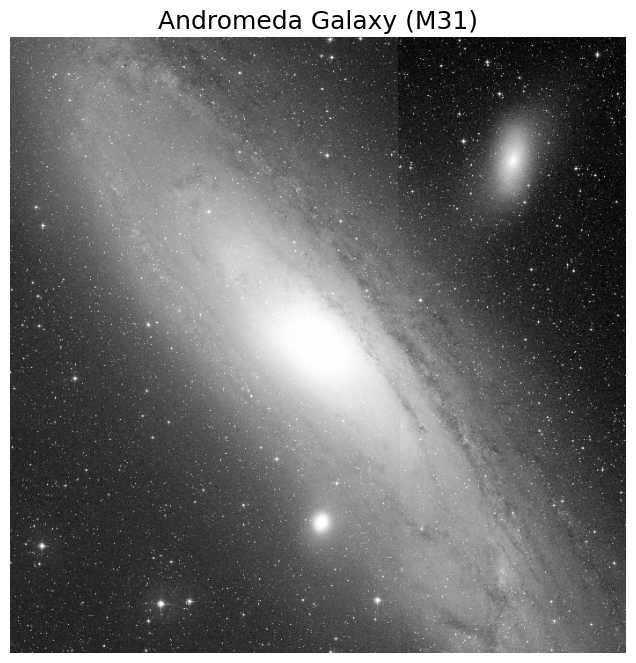

In [404]:
plt.figure(figsize=(8, 8))

plt.imshow(
    preview_data,
    cmap="gray",
    origin="lower",
    norm=preview_norm
)

plt.title(object_name, fontsize=18)
plt.axis("off")
plt.show()

## Step 11 — Plot the colour version you chose

Now we display the **same telescope data** using the colour map selected in Step 5.

The colour is a visualisation of brightness. It does not mean the telescope recorded the object in these exact colours.

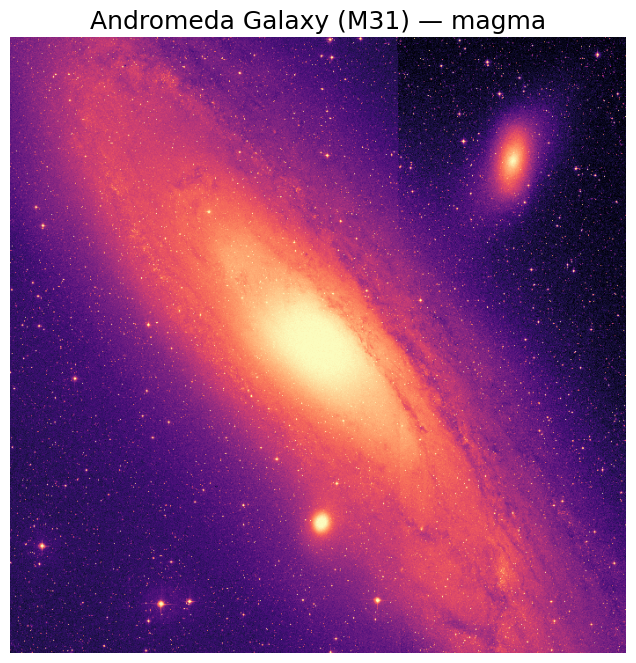

In [405]:
plt.figure(figsize=(8, 8))

plt.imshow(
    preview_data,
    cmap=colour_map,
    origin="lower",
    norm=preview_norm
)

plt.title(f"{object_name} — {colour_map}", fontsize=18)
plt.axis("off")
plt.show()

## Step 12 — Compare black and white with your colour map

Both panels contain the same astronomical data.

Only the way we display the pixel values is different.

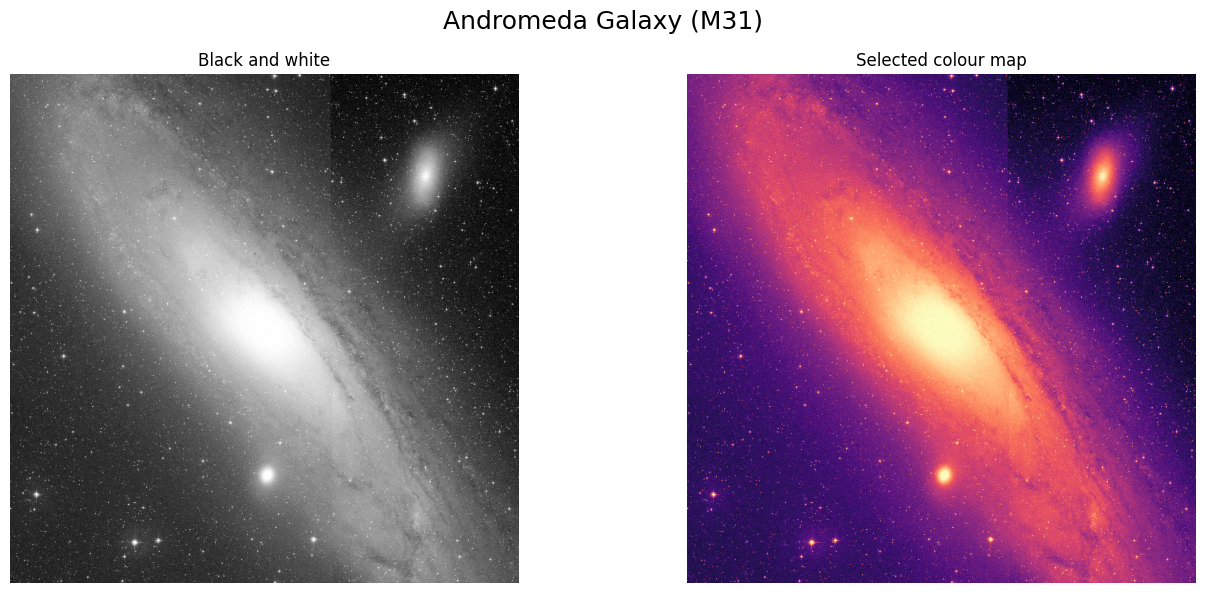

In [406]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(
    preview_data,
    cmap="gray",
    origin="lower",
    norm=preview_norm
)
axes[0].set_title("Black and white")
axes[0].axis("off")

axes[1].imshow(
    preview_data,
    cmap=colour_map,
    origin="lower",
    norm=preview_norm
)
axes[1].set_title("Selected colour map")
axes[1].axis("off")

plt.suptitle(object_name, fontsize=18)
plt.tight_layout()
plt.show()

# Now we will make the RGB composite

For this part we use **three real survey images of the same target**.

We use:

- **DSS2 Blue**
- **DSS2 Red**
- **DSS2 IR**

We will place them in wavelength order to make a representative-colour RGB image.

## Step 13 — Download the blue band

In [407]:
print("Downloading DSS2 Blue...")

try:
    blue_band = download_band(
        position,
        "DSS2 Blue",
        radius_deg,
        pixels=700
    )
    blue_band_name = "DSS2 Blue"
except HTTPError:
    print("DSS2 Blue not found, trying DSS1 Blue...")
    blue_band = download_band(
        position,
        "DSS1 Blue",
        radius_deg,
        pixels=700
    )
    blue_band_name = "DSS1 Blue"

print(f"{blue_band_name} band ready.")

DSS2 Blue band ready.


## Step 14 — Download the red band

In [408]:
print("Downloading DSS2 Red...")

middle_band = download_band(
    position,
    "DSS2 Red",
    radius_deg,
    pixels=700
)

print("Red band ready.")

Red band ready.


## Step 15 — Download the near-infrared band

In [409]:
print("Downloading DSS2 IR...")

long_band = download_band(
    position,
    "DSS2 IR",
    radius_deg,
    pixels=700
)

print("Near-infrared band ready.")

Near-infrared band ready.


## Step 16 — Look at the three bands

Each panel is a separate observation of the same target.

The object can look slightly different because each survey band records a different wavelength range.

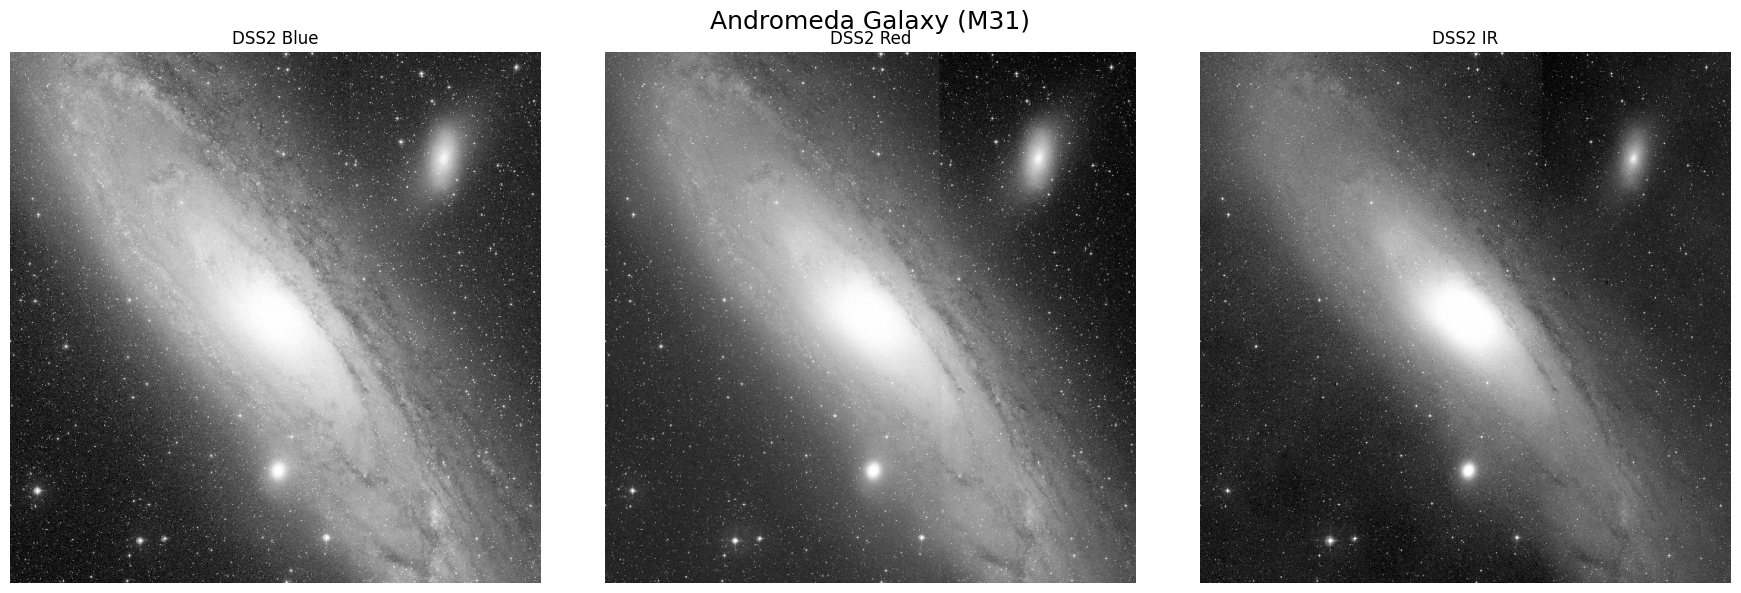

In [410]:
bands = [
    ("DSS2 Blue", blue_band),
    ("DSS2 Red", middle_band),
    ("DSS2 IR", long_band)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (title, band) in zip(axes, bands):

    band_interval = PercentileInterval(99.5)

    band_vmin, band_vmax = band_interval.get_limits(
        band[np.isfinite(band)]
    )

    band_norm = ImageNormalize(
        vmin=band_vmin,
        vmax=band_vmax,
        stretch=AsinhStretch()
    )

    ax.imshow(
        band,
        cmap="gray",
        origin="lower",
        norm=band_norm
    )

    ax.set_title(title)
    ax.axis("off")

plt.suptitle(object_name, fontsize=18)
plt.tight_layout()
plt.show()

## Step 17 — Make a small stretching function

Before combining the bands, we scale each one between 0 and 1.

The asinh stretch helps us keep both faint and bright structure visible.

In [411]:
def stretch_to_unit(data, percentile=99.5):

    finite = np.isfinite(data)

    interval = PercentileInterval(percentile)

    vmin, vmax = interval.get_limits(
        data[finite]
    )

    scaled = (data - vmin) / (vmax - vmin)

    scaled = np.clip(
        scaled,
        0,
        1
    )

    stretched = np.arcsinh(5 * scaled) / np.arcsinh(5)

    stretched[~finite] = 0

    return stretched

print("Stretch function ready.")

Stretch function ready.


## Step 18 — Stretch each band

We now prepare the three survey bands for RGB.

In [412]:
B = stretch_to_unit(blue_band)
G = stretch_to_unit(middle_band)
R = stretch_to_unit(long_band)

print("All three bands are ready.")

All three bands are ready.


## Step 19 — Build the RGB image

We combine the bands in wavelength order:

- longer wavelength → **Red**
- middle wavelength → **Green**
- shorter wavelength → **Blue**

This is a **representative-colour RGB composite** made from real astronomical survey data.

In [413]:
rgb_image = np.dstack([
    R,
    G,
    B
])

print("RGB image created.")

RGB image created.


## Step 20 — Plot your final RGB image

This is the final multi-band image of the target you selected.

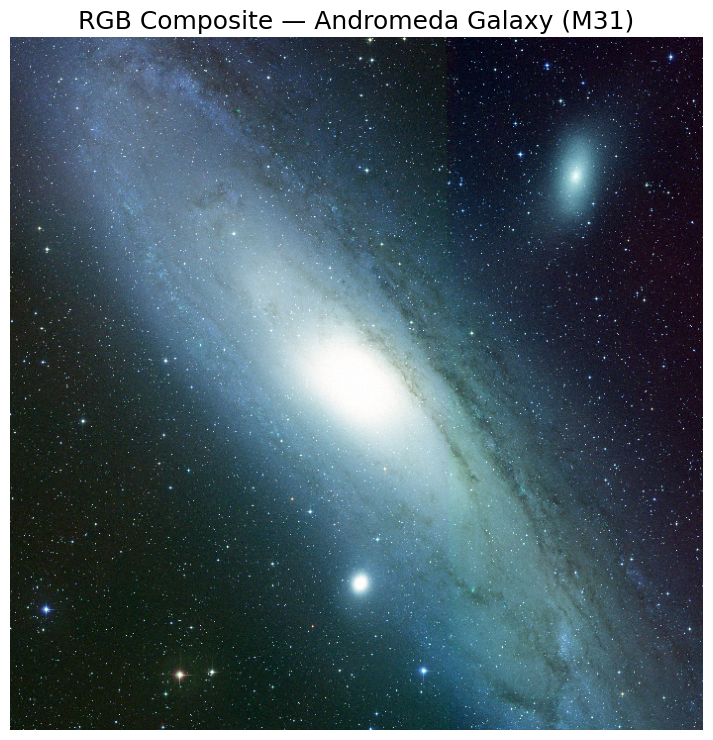

In [414]:
plt.figure(figsize=(9, 9))

plt.imshow(
    rgb_image,
    origin="lower"
)

plt.title(
    f"RGB Composite — {object_name}",
    fontsize=18
)

plt.axis("off")
plt.show()

## Step 21 — Save the RGB image

This cell saves your final image as a PNG file.

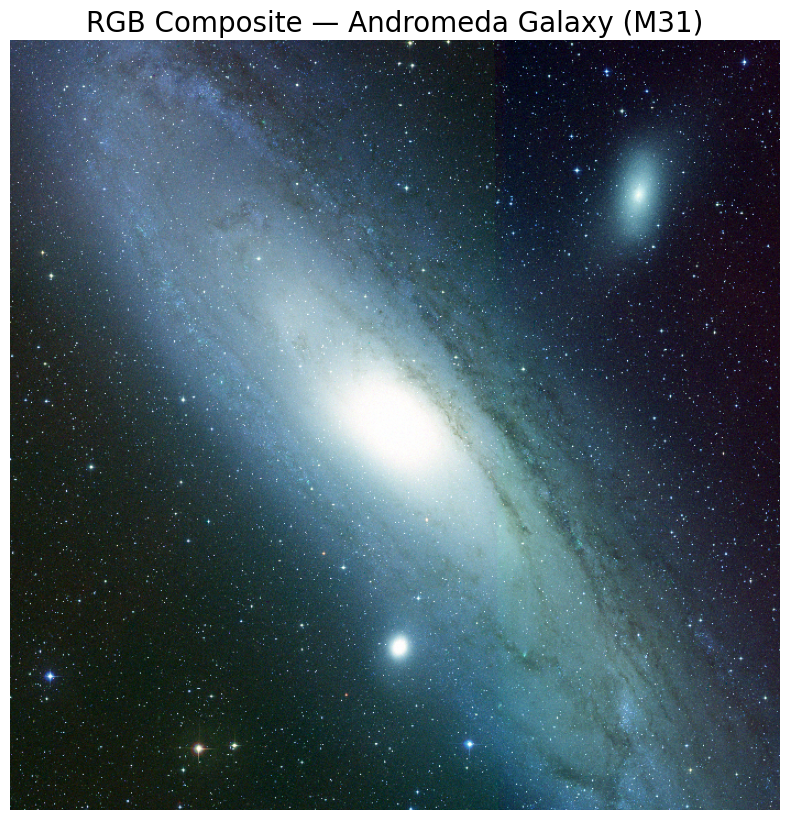

Saved as: RGB_Andromeda_Galaxy_M31.png


In [415]:
safe_name = (
    object_name
    .replace(" ", "_")
    .replace("(", "")
    .replace(")", "")
)

rgb_filename = f"RGB_{safe_name}.png"

plt.figure(figsize=(10, 10))

plt.imshow(
    rgb_image,
    origin="lower"
)

plt.title(
    f"RGB Composite — {object_name}",
    fontsize=20
)

plt.axis("off")

plt.savefig(
    rgb_filename,
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

print("Saved as:", rgb_filename)

## Step 22 — Download your image

Run this last cell to download the PNG file to your device.

In [416]:
files.download(rgb_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Finished

You have used Python to:

- choose an astronomical target,
- download real survey data,
- display a single-band image,
- try a colour map,
- download three wavelength bands,
- and combine them into one RGB composite.

Try choosing another target or colour in **Step 5** and run the notebook again.